<a href="https://colab.research.google.com/github/Dipanjan-Chaudhuri/Floquet-BEC-SSFM-Solver/blob/main/GPE_SSFM_solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
3D SSFM solver for driven GPE:
  i hbar dPsi/dt = [ -hbar^2/2m Lap + V(r)*Gamma_D*Sgn(cos(wt)) + g|Psi|^2 ] Psi
"""
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [ ]:
# ---------------- Parameters ----------------
hbar = 1.0
m    = 1.0
omega_trap = 1.0
g    = 0.5

# Keep grid modest -- 3D memory/cost grows as N^3
Nx = Ny = Nz = 32
Lx = Ly = Lz = 10.0
dx, dy, dz = Lx/Nx, Ly/Ny, Lz/Nz

x = (np.arange(Nx) - Nx//2) * dx
y = (np.arange(Ny) - Ny//2) * dy
z = (np.arange(Nz) - Nz//2) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
R = np.sqrt(X**2 + Y**2 + Z**2)

kx = 2*np.pi*np.fft.fftfreq(Nx, d=dx)
ky = 2*np.pi*np.fft.fftfreq(Ny, d=dy)
kz = 2*np.pi*np.fft.fftfreq(Nz, d=dz)
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
K2 = KX**2 + KY**2 + KZ**2

dV = dx*dy*dz   # volume element

T = 6.2832
A0(t) range over a period: [0.2569, 14.6572]
Period-averaged A0: 4.681126
<T0>(t) range over a period: [0.7385, 42.9095]
Period-averaged <T0> (kinetic, via Parseval): 14.369922
E_0(t) range over a period: [0.0004, 0.3543]
Period-averaged E_0 (interaction): 0.018109


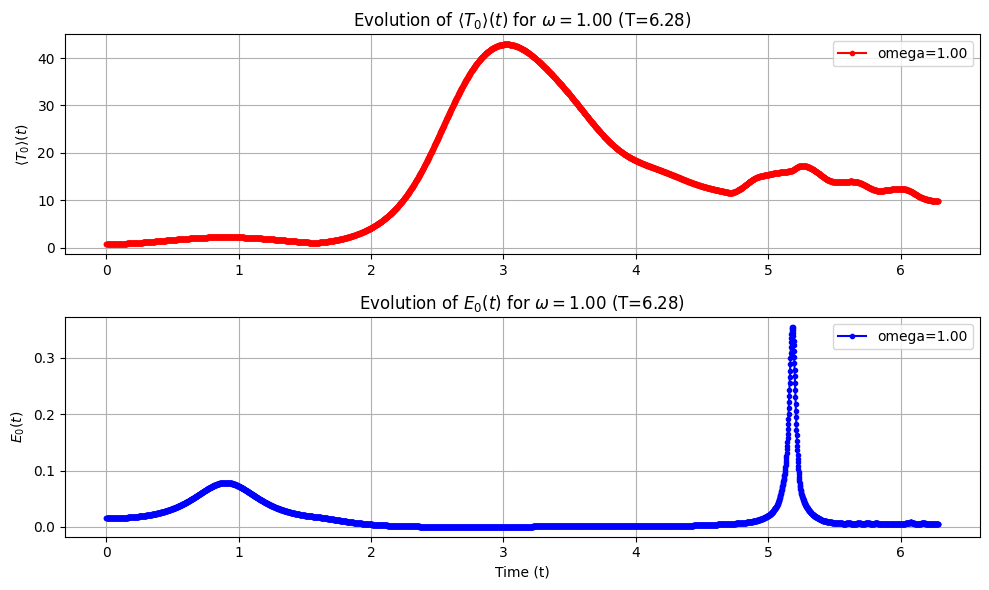

In [ ]:
# ---------------- Run ----------------
if __name__ == "__main__":
    psi_gs = find_ground_state(Npart=1.0)

    all_times = []
    all_A0_t = []
    all_T_t = [] # New list to store kinetic energy for all omegas
    all_I_0000_t = [] # New list to store interaction energy for all omegas
    all_T_period = []
    all_A0_avg = []
    all_T_avg = [] # New list for period-averaged kinetic energy
    all_I_0000_avg = [] # New list for period-averaged interaction energy

    for i, current_omega in enumerate(omega):
        T_period = 2 * np.pi / current_omega
        all_T_period.append(T_period)

        times, A0_t, T_t, I_0000_t, psi_final = evolve_driven(
                                      psi_gs, current_omega, T_period,
                                      n_periods=1, steps_per_period=4000)

        all_times.append(times)
        all_A0_t.append(A0_t)
        all_T_t.append(T_t) # Store T_t for plotting
        all_I_0000_t.append(I_0000_t) # Store I_0000_t for analysis

        A0_avg = period_average(times, A0_t, T_period)
        T_avg  = period_average(times, T_t, T_period)
        I_0000_avg = period_average(times, I_0000_t, T_period)

        all_A0_avg.append(A0_avg)
        all_T_avg.append(T_avg)
        all_I_0000_avg.append(I_0000_avg)

        print(f"T = {T_period:.4f}")
        print(f"A0(t) range over a period: [{np.min(A0_t):.4f}, {np.max(A0_t):.4f}]")
        print(f"Period-averaged A0: {A0_avg:.6f}")
        print(f"<T0>(t) range over a period: [{np.min(T_t):.4f}, {np.max(T_t):.4f}]")
        print(f"Period-averaged <T0> (kinetic, via Parseval): {T_avg:.6f}")
        print(f"E_0(t) range over a period: [{np.min(I_0000_t):.4f}, {np.max(I_0000_t):.4f}]")
        print(f"Period-averaged E_0 (interaction): {I_0000_avg:.6f}")

    # Plot the evolution of T_t and I_0000_t over time for all frequencies in subplots
    num_omegas = len(omega)
    fig, axes = plt.subplots(num_omegas * 2, 1, figsize=(10, 6 * num_omegas), sharex=False)

    # The 'axes' object is already a 1D array of Axes objects if num_omegas * 2 > 1
    # if num_omegas == 1, then num_omegas * 2 is 2, so axes is a 1D array of 2 Axes objects.
    # No need to convert to np.array([axes]) as it causes issues when accessing individual axes.

    for i, current_omega in enumerate(omega):
        # Plot for T_t
        ax_T = axes[i*2] # First subplot for each omega
        ax_T.plot(all_times[i], all_T_t[i], '.-', label=f'omega={current_omega:.2f}', color='red')
        ax_T.set_ylabel(r'$\langle T_{0} \rangle(t)$')
        ax_T.set_title(rf'Evolution of $\langle T_{0} \rangle(t)$ for $\omega={current_omega:.2f}$' + f' (T={all_T_period[i]:.2f})')
        ax_T.grid(True)
        ax_T.legend()

        # Plot for I_0000_t
        ax_I = axes[i*2 + 1] # Second subplot for each omega
        ax_I.plot(all_times[i], all_I_0000_t[i], '.-', label=f'omega={current_omega:.2f}', color='blue')
        ax_I.set_ylabel(r'$E_{0}(t)$')
        ax_I.set_title(rf'Evolution of $E_{0}(t)$ for $\omega={current_omega:.2f}$' + f' (T={all_T_period[i]:.2f})')
        ax_I.set_xlabel('Time (t)')
        ax_I.grid(True)
        ax_I.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def V_ext(R):
    return 0.5 * m * omega_trap * R**2       # e.g. isotropic harmonic trap; swap for your V(r)

Vr = V_ext(R)

Gamma_D = 3.0
omega   = [1.0]
# T_period = 2*np.pi/omega[4]  # This will now be calculated in the loop

In [ ]:
# ---------------- Split-step propagator ----------------
def ssfm_step(psi, dt, Vt, imaginary=False):
    if imaginary:
        expK = np.exp(-(hbar*K2/(2*m)) * (dt/2))
        def expV(psi): return np.exp(-(Vt + g*np.abs(psi)**2) * dt / hbar)
    else:
        expK = np.exp(-1j*(hbar*K2/(2*m)) * (dt/2))
        def expV(psi): return np.exp(-1j*(Vt + g*np.abs(psi)**2) * dt / hbar)

    psi = np.fft.ifftn(expK * np.fft.fftn(psi))
    psi = expV(psi) * psi
    psi = np.fft.ifftn(expK * np.fft.fftn(psi))
    return psi

def normalize(psi, Ntarget=1.0):
    norm = np.sum(np.abs(psi)**2) * dV
    return psi * np.sqrt(Ntarget/norm)

In [ ]:
from scipy import integrate

# ---------------- Ground state ----------------
def find_ground_state(Npart=1.0, dt=1e-3, tol=1e-10, max_iter=20000):
    psi = np.exp(-R**2/4).astype(complex)
    psi = normalize(psi, Npart)
    mu_old = 1e10
    for it in range(max_iter):
        psi = ssfm_step(psi, dt, Vr, imaginary=True)
        psi = normalize(psi, Npart)
        if it % 200 == 0:
            psi_k = np.fft.fftn(psi)
            KE = np.sum(hbar**2*K2/(2*m) * np.abs(psi_k)**2) / (Nx*Ny*Nz) * dV
            PE = np.sum((Vr + 0.5*g*np.abs(psi)**2) * np.abs(psi)**2) * dV
            mu = KE + PE
            if abs(mu - mu_old) < tol:
                break
            mu_old = mu
    return psi

def kinetic_expectation(psi, K2, dV, N_total, hbar, m, Nx, Ny, Nz):
    """Calculates the kinetic energy expectation value.
    N_total is the normalization factor (total number of particles).
    """
    psi_k = np.fft.fftn(psi)
    KE_total = np.sum(hbar**2 * K2 / (2 * m) * np.abs(psi_k)**2) / (Nx * Ny * Nz) * dV
    return KE_total / N_total

# ---------------- Real-time driven propagation ----------------
def evolve_driven(psi0, current_omega, current_T_period, n_periods, steps_per_period):
    dt = current_T_period / steps_per_period
    n_steps = n_periods * steps_per_period

    psi = psi0.copy()
    times, A0_t, T_t_list, I_0000_t_list = [], [], [], []

    t = 0.0
    # Calculate N_total once from the initial state, as it should be conserved
    N_total = np.sum(np.abs(psi0)**2) * dV

    for step in range(n_steps):
        drive_sign = np.sign(np.cos(current_omega * t))
        Vt = Vr * Gamma_D * drive_sign

        psi = ssfm_step(psi, dt, Vt, imaginary=False)
        t += dt

        A0 = np.sum(Vr * np.abs(psi)**2) * dV / N_total
        T_exp = kinetic_expectation(psi, K2, dV, N_total, hbar, m, Nx, Ny, Nz)
        # Calculate I_0000 as the interaction expectation value
        I_0000 = 0.5 * g * np.sum(np.abs(psi)**4) * dV / N_total

        times.append(t)
        A0_t.append(A0)
        T_t_list.append(T_exp)
        I_0000_t_list.append(I_0000)

    return np.array(times), np.array(A0_t), np.array(T_t_list), np.array(I_0000_t_list), psi # return final psi

def period_average(times, quantity_t, T):
    mask = times <= T
    tt, qq = times[mask], quantity_t[mask]
    return integrate.trapezoid(qq, tt) / T